In [1]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
import kagglehub
import os
import json

# Download dataset
path = kagglehub.dataset_download("nirmalsankalana/rice-leaf-disease-image")

print("Dataset Path:", path)

# Show files
print(os.listdir(path))

100%|██████████| 195M/195M [00:02<00:00, 97.7MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/nirmalsankalana/rice-leaf-disease-image/versions/1
['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [3]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Class names
class_names = train_data.class_names

print("Classes:", class_names)

Found 5932 files belonging to 4 classes.
Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [4]:
import os

# Count images per class
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(path, class_name)

    total_images = len([
        file for file in os.listdir(class_path)
        if file.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    class_counts[class_name] = total_images

# Print results
for class_name, count in class_counts.items():
    print(f"{class_name}: {count} images")

Bacterialblight: 1584 images
Blast: 1440 images
Brownspot: 1600 images
Tungro: 1308 images


In [5]:
import os
import random
import shutil

# ==========================================
# ORIGINAL DATASET PATH
# ==========================================

dataset_path = path

# ==========================================
# NEW BALANCED DATASET
# ==========================================

balanced_path = "/content/balanced_rice_dataset"

# ==========================================
# DELETE OLD FOLDER IF EXISTS
# ==========================================

if os.path.exists(balanced_path):
    shutil.rmtree(balanced_path)

os.makedirs(balanced_path)

# ==========================================
# MINIMUM CLASS COUNT
# ==========================================

min_images = 1308

# ==========================================
# BALANCE DATASET
# ==========================================

for class_name in class_names:

    source_folder = os.path.join(dataset_path, class_name)

    target_folder = os.path.join(balanced_path, class_name)

    os.makedirs(target_folder)

    # Get image files
    images = [

        img for img in os.listdir(source_folder)

        if img.lower().endswith(
            ('.png', '.jpg', '.jpeg')
        )
    ]

    # Random selection
    selected_images = random.sample(
        images,
        min_images
    )

    # Copy images
    for img in selected_images:

        src = os.path.join(source_folder, img)

        dst = os.path.join(target_folder, img)

        shutil.copy(src, dst)

print("Balanced dataset created successfully!")

Balanced dataset created successfully!


In [6]:
for class_name in class_names:

    folder = os.path.join(
        balanced_path,
        class_name
    )

    count = len(os.listdir(folder))

    print(f"{class_name}: {count}")

Bacterialblight: 1308
Blast: 1308
Brownspot: 1308
Tungro: 1308


In [7]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    balanced_path,
    image_size=(224,224),
    batch_size=32
)

Found 5232 files belonging to 4 classes.


In [8]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    balanced_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

class_names = dataset.class_names

print("Classes:", class_names)

Found 5232 files belonging to 4 classes.
Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [9]:
dataset_size = len(dataset)

train_size = int(0.7 * dataset_size)
val_size = int(0.2 * dataset_size)

train_data = dataset.take(train_size)

remaining = dataset.skip(train_size)

val_data = remaining.take(val_size)

test_data = remaining.skip(val_size)

print("Train batches:", len(train_data))
print("Validation batches:", len(val_data))
print("Test batches:", len(test_data))

Train batches: 114
Validation batches: 32
Test batches: 18


In [10]:
import numpy as np

# Function to count labels
def count_classes(dataset, class_names):

    counts = {name: 0 for name in class_names}

    for images, labels in dataset:
        labels = labels.numpy()

        for label in labels:
            counts[class_names[label]] += 1

    return counts


# Train counts
train_counts = count_classes(train_data, class_names)

# Validation counts
val_counts = count_classes(val_data, class_names)

# Test counts
test_counts = count_classes(test_data, class_names)

print("Train Distribution")
print(train_counts)

print("\nValidation Distribution")
print(val_counts)

print("\nTest Distribution")
print(test_counts)

Train Distribution
{'Bacterialblight': 921, 'Blast': 930, 'Brownspot': 889, 'Tungro': 908}

Validation Distribution
{'Bacterialblight': 258, 'Blast': 248, 'Brownspot': 254, 'Tungro': 264}

Test Distribution
{'Bacterialblight': 137, 'Blast': 131, 'Brownspot': 150, 'Tungro': 142}


In [11]:
# Count total images

train_images = 0
val_images = 0
test_images = 0

for images, labels in train_data:
    train_images += images.shape[0]

for images, labels in val_data:
    val_images += images.shape[0]

for images, labels in test_data:
    test_images += images.shape[0]

print("Total Train Images:", train_images)
print("Total Validation Images:", val_images)
print("Total Test Images:", test_images)

Total Train Images: 3648
Total Validation Images: 1024
Total Test Images: 560


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

# Function to convert labels to one-hot encoding
num_classes = len(class_names)
def one_hot_encode_labels(image, label):
    label = tf.one_hot(label, num_classes)
    return image, label

# Apply one-hot encoding to all datasets
train_data = train_data.map(one_hot_encode_labels, num_parallel_calls=AUTOTUNE)
val_data = val_data.map(one_hot_encode_labels, num_parallel_calls=AUTOTUNE)
test_data = test_data.map(one_hot_encode_labels, num_parallel_calls=AUTOTUNE)

train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data = val_data.prefetch(buffer_size=AUTOTUNE)
test_data = test_data.prefetch(buffer_size=AUTOTUNE)

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)
])

In [14]:
counts = list(train_counts.values())
names = class_names
values = counts

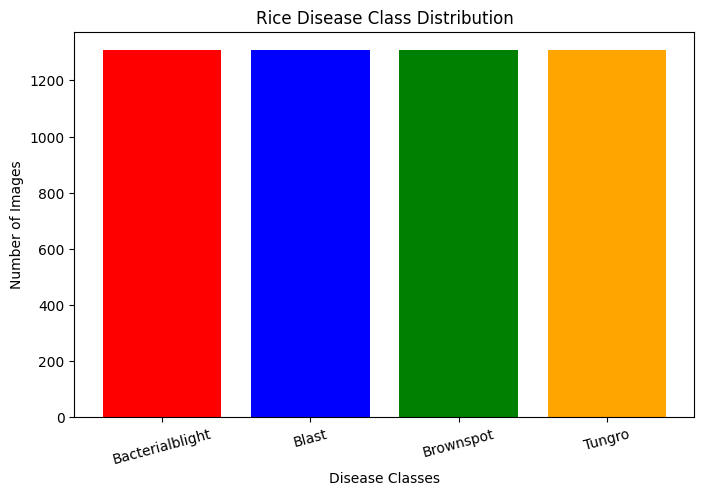

In [15]:
import matplotlib.pyplot as plt

# Your rice disease classes
classes = ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']

# Balanced image counts
counts = [1308, 1308, 1308, 1308]

# Colors for each disease
colors = ['red', 'blue', 'green', 'orange']

plt.figure(figsize=(8,5))

plt.bar(classes, counts, color=colors)

plt.title("Rice Disease Class Distribution")
plt.xlabel("Disease Classes")
plt.ylabel("Number of Images")

plt.xticks(rotation=15)

plt.show()

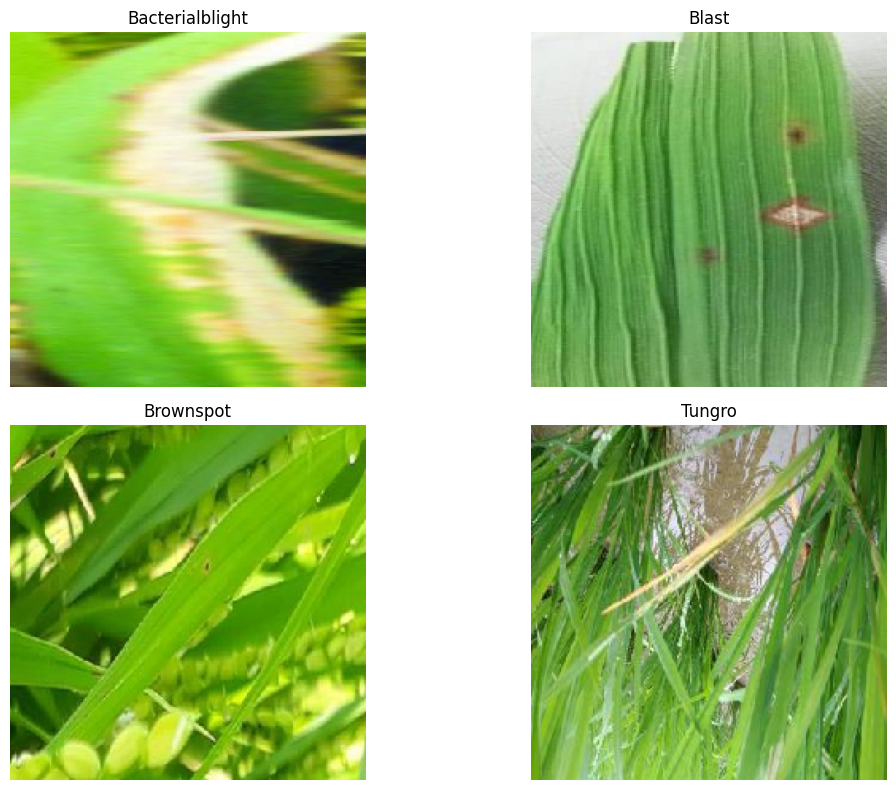

In [16]:
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image

# Show one image from each class

plt.figure(figsize=(12,8))

for i, class_name in enumerate(class_names):

    class_path = os.path.join(balanced_path, class_name)

    # First image in folder
    img_name = os.listdir(class_path)[0]

    img_path = os.path.join(class_path, img_name)

    # Load image
    img = image.load_img(img_path, target_size=(224,224))

    # Plot image
    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()

plt.show()

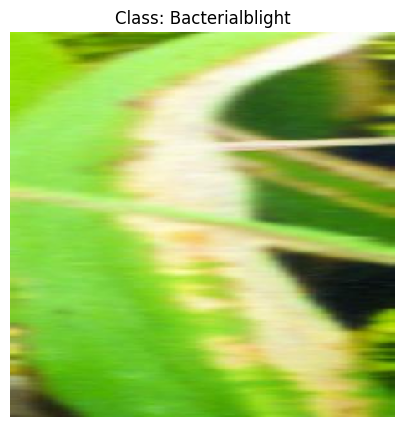

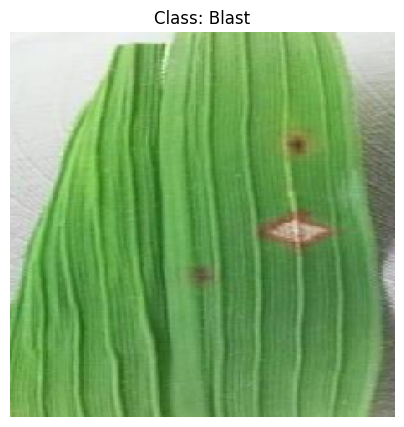

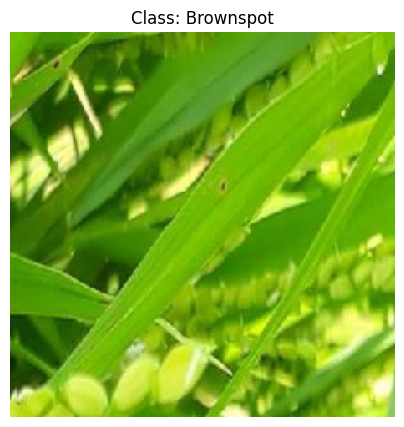

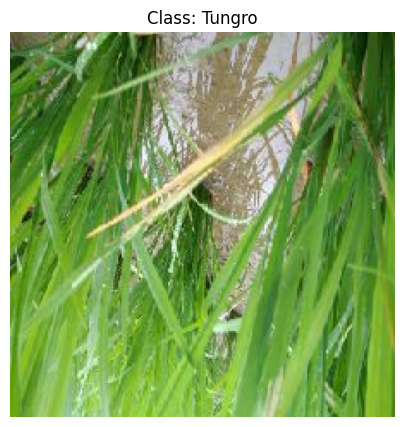

In [17]:
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image

# Show images one by one for each class

for class_name in class_names:

    class_path = os.path.join(balanced_path, class_name)

    # Get first image
    img_name = os.listdir(class_path)[0]

    img_path = os.path.join(class_path, img_name)

    # Load image
    img = image.load_img(img_path, target_size=(224,224))

    # Display image
    plt.figure(figsize=(5,5))

    plt.imshow(img)

    plt.title(f"Class: {class_name}")

    plt.axis("off")

    plt.show()

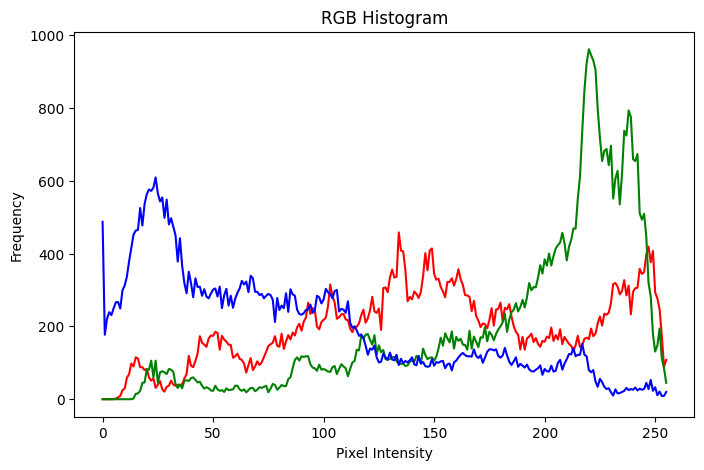

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Get a sample image path from the balanced dataset (e.g., from the first class)
class_name = class_names[0] # Using 'Bacterialblight' from kernel state
class_path = os.path.join(balanced_path, class_name)

if os.path.exists(class_path) and os.listdir(class_path):
    img_name = os.listdir(class_path)[0]
    image_path_for_hist = os.path.join(class_path, img_name)

    # Load image using OpenCV (loads as BGR by default)
    img_bgr = cv2.imread(image_path_for_hist)

    if img_bgr is None:
        print(f"Error: Could not load image at {image_path_for_hist}")
    else:
        # Resize the image (IMG_SIZE is (224, 224) from kernel state)
        resized = cv2.resize(img_bgr, IMG_SIZE)

        # Convert BGR to RGB for consistent plotting with 'red', 'green', 'blue' order
        img_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

        colors = ("red", "green", "blue")

        plt.figure(figsize=(8,5))

        # Split the RGB image into its channels
        channels = cv2.split(img_rgb) # channels[0]=R, channels[1]=G, channels[2]=B

        for i, color in enumerate(colors):
            # Calculate histogram for each channel
            hist = cv2.calcHist([channels[i]], [0], None, [256], [0,256])
            plt.plot(hist, color=color)

        plt.title("RGB Histogram")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")
        plt.show()
else:
    print(f"Error: Class path {class_path} not found or is empty.")

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [20]:
dataset_path = "/content/balanced_rice_dataset"

In [21]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [22]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,

    validation_split=0.2,

    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,

    horizontal_flip=True,

    brightness_range=[0.8, 1.2],

    fill_mode='nearest'
)

In [23]:
valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

In [24]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training',

    shuffle=True,

    seed=SEED
)

Found 4188 images belonging to 4 classes.


In [25]:
valid_generator = valid_datagen.flow_from_directory(
    dataset_path,

    target_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False,

    seed=SEED
)

Found 1044 images belonging to 4 classes.


In [26]:
class_names = list(train_generator.class_indices.keys())

print(class_names)

['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [27]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [28]:
base_model.trainable = True

In [29]:
for layer in base_model.layers[:100]:
    layer.trainable = False

In [30]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dropout(0.4)(x)

x = Dense(
    256,
    activation='relu'
)(x)

x = BatchNormalization()(x)

x = Dropout(0.3)(x)

output = Dense(
    len(class_names),
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [31]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [32]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    '/content/best_model.keras',

    monitor='val_accuracy',

    save_best_only=True,

    verbose=1
)

callbacks = [
    early_stop,
    reduce_lr,
    checkpoint
]

In [33]:
history = model.fit(
    train_generator,

    validation_data=valid_generator,

    epochs=20,

    callbacks=callbacks
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 732ms/step - accuracy: 0.6249 - loss: 1.0085
Epoch 1: val_accuracy improved from None to 0.94732, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 195s 989ms/step - accuracy: 0.7775 - loss: 0.6109 - val_accuracy: 0.9473 - val_loss: 0.2388 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.9304 - loss: 0.2005
Epoch 2: val_accuracy improved from 0.94732 to 0.99808, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 65s 498ms/step - accuracy: 0.9468 - loss: 0.1591 - val_accuracy: 0.9981 - val_loss: 0.0295 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.9789 - loss: 0.0691
Epoch 3: val_accuracy improved from 0.99808 to 1.00000, saving model to /content/best_model.keras

Epoch 3: finished saving 

In [34]:
loss, accuracy = model.evaluate(valid_generator)

print("Validation Accuracy:", accuracy)

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 1.0000 - loss: 0.0047
Validation Accuracy: 1.0


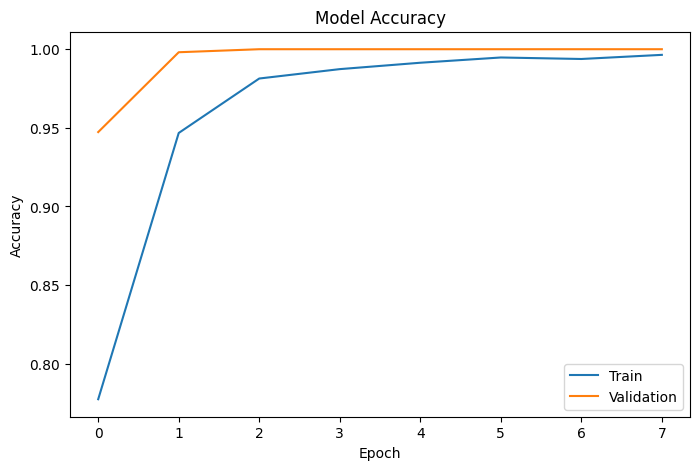

In [35]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [38]:
# ==========================================
# RESET VALIDATION GENERATOR
# ==========================================

valid_generator.reset()

# ==========================================
# PREDICT
# ==========================================

pred_probs = model.predict(valid_generator)

# ==========================================
# PREDICTED CLASSES
# ==========================================

pred_classes = np.argmax(
    pred_probs,
    axis=1
)

# ==========================================
# TRUE CLASSES
# ==========================================

true_classes = valid_generator.classes

# ==========================================
# CLASS NAMES
# ==========================================

class_labels = list(
    valid_generator.class_indices.keys()
)

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
))

33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 327ms/step
                 precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00       261
          Blast       1.00      1.00      1.00       261
      Brownspot       1.00      1.00      1.00       261
         Tungro       1.00      1.00      1.00       261

       accuracy                           1.00      1044
      macro avg       1.00      1.00      1.00      1044
   weighted avg       1.00      1.00      1.00      1044



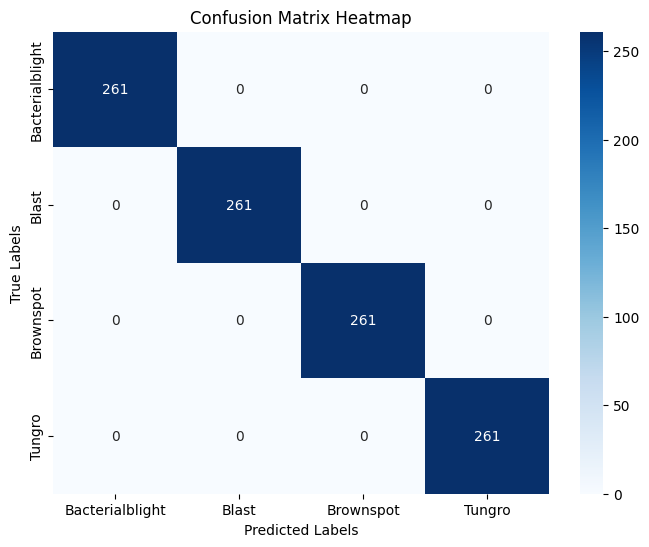

In [39]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    true_classes,
    pred_classes
)

# ==========================================
# PLOT HEATMAP
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

# ==========================================
# LABELS
# ==========================================

plt.xlabel("Predicted Labels")

plt.ylabel("True Labels")

plt.title("Confusion Matrix Heatmap")

# ==========================================
# SHOW PLOT
# ==========================================

plt.show()

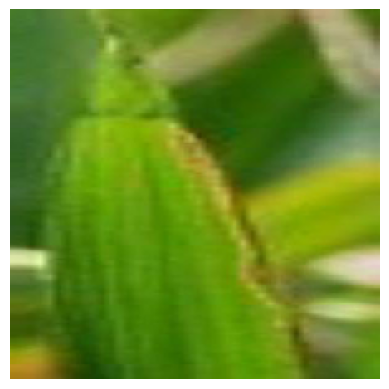

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Predicted Disease: Bacterialblight
Confidence: 99.91553


In [41]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications.efficientnet import preprocess_input

# ==========================================
# CLASS NAMES
# ==========================================

class_names = [
    'Bacterialblight',
    'Blast',
    'Brownspot',
    'Tungro'
]

# ==========================================
# IMAGE PATH
# ==========================================

# Updated image path to use an existing image from the balanced dataset
img_path = "/content/balanced_rice_dataset/Bacterialblight/BACTERIALBLIGHT_001.jpg"

# ==========================================
# LOAD IMAGE
# ==========================================

img = image.load_img(
    img_path,
    target_size=(224,224)
)

# ==========================================
# DISPLAY IMAGE
# ==========================================

plt.imshow(img)
plt.axis('off')
plt.show()

# ==========================================
# IMAGE TO ARRAY
# ==========================================

img_array = image.img_to_array(img)

# ==========================================
# EXPAND DIMENSIONS
# ==========================================

img_array = np.expand_dims(
    img_array,
    axis=0
)

# ==========================================
# PREPROCESS IMAGE
# ==========================================

img_array = preprocess_input(img_array)

# ==========================================
# PREDICTION
# ==========================================

prediction = model.predict(img_array)

# ==========================================
# PREDICTED CLASS
# ==========================================

predicted_index = np.argmax(prediction)

predicted_class = class_names[predicted_index]

# ==========================================
# CONFIDENCE SCORE
# ==========================================

confidence = np.max(prediction) * 100

# ==========================================
# PRINT RESULT
# ==========================================

print("Predicted Disease:", predicted_class)

print("Confidence:", confidence)

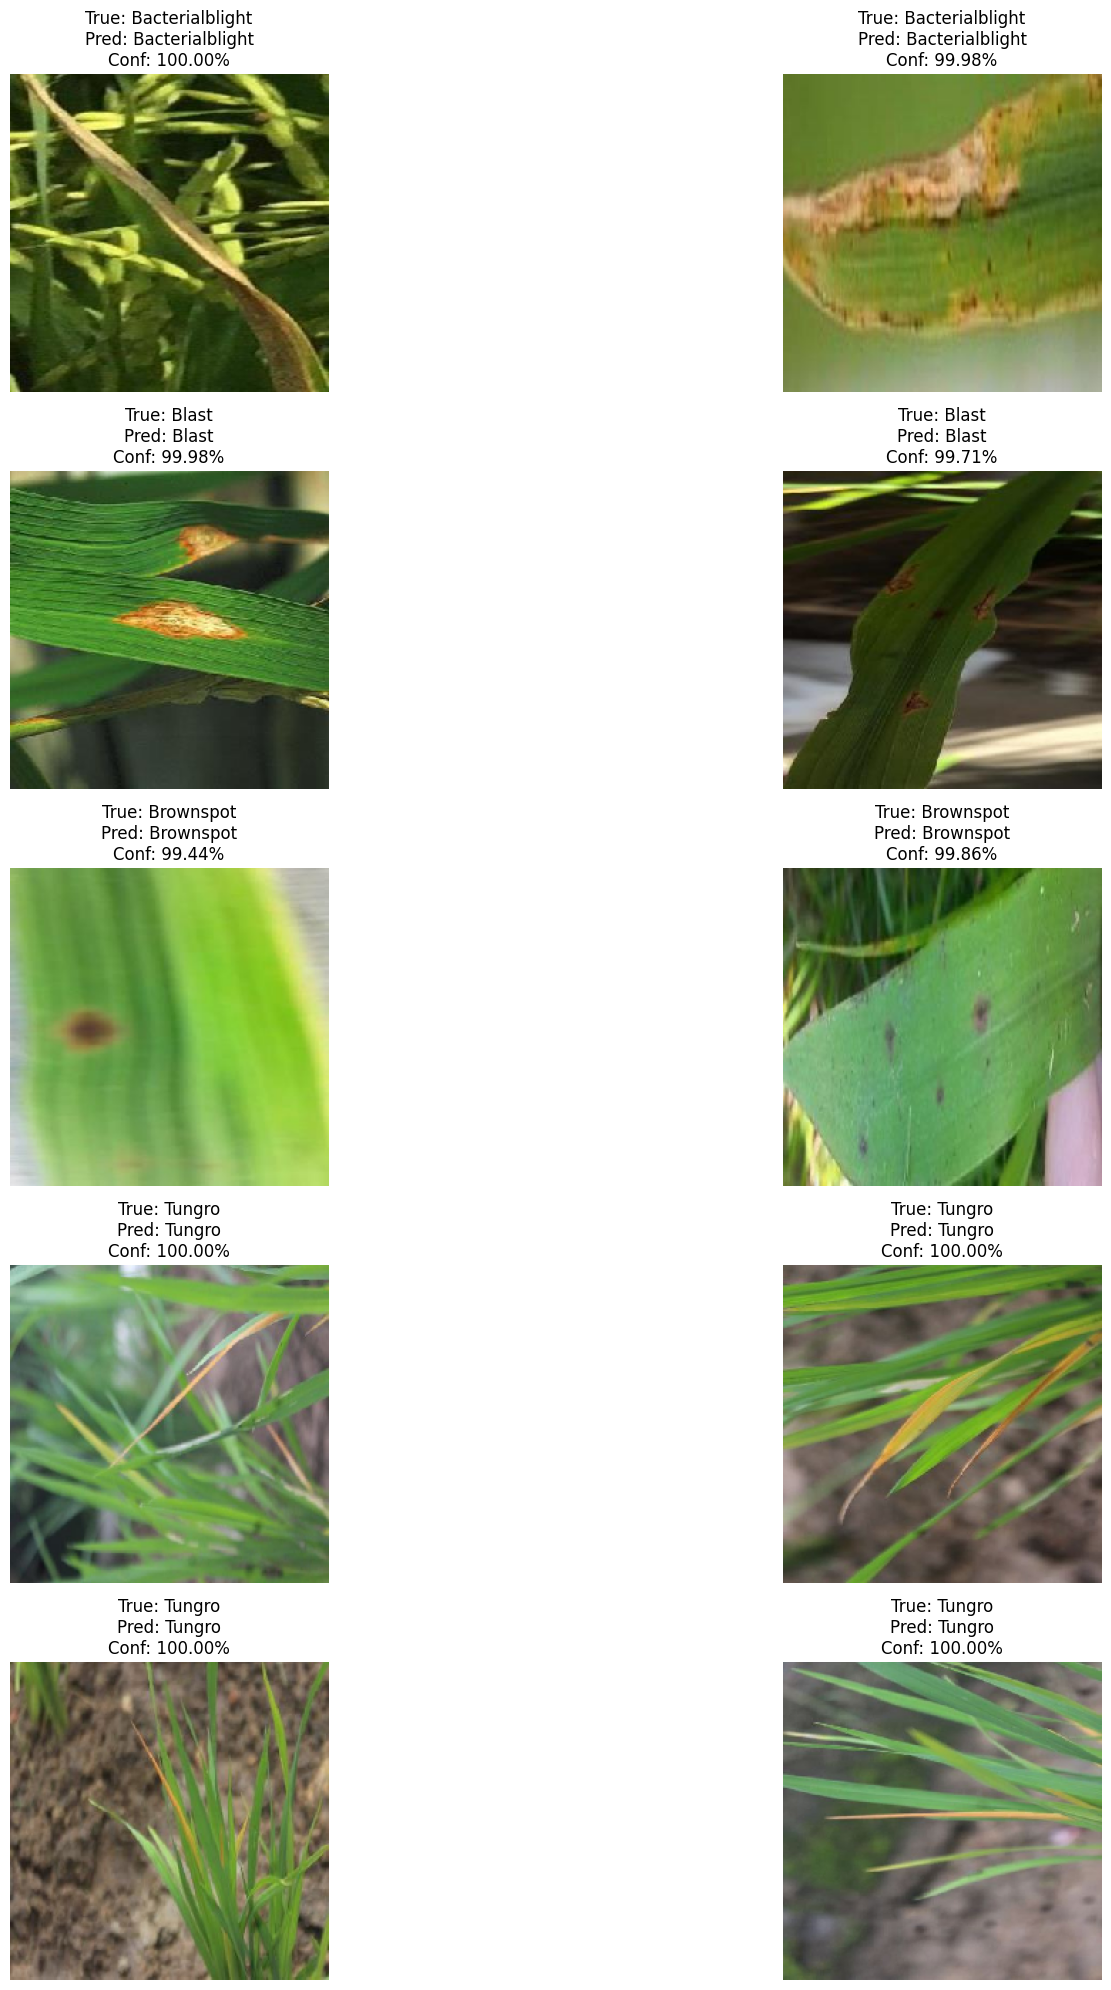

In [42]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications.efficientnet import preprocess_input

# ==========================================
# DATASET PATH
# ==========================================

dataset_path = balanced_path

# ==========================================
# CLASS NAMES
# ==========================================

class_names = [
    'Bacterialblight',
    'Blast',
    'Brownspot',
    'Tungro'
]

# ==========================================
# COLLECT RANDOM IMAGES
# ==========================================

selected_images = []

for class_name in class_names:

    class_folder = os.path.join(
        dataset_path,
        class_name
    )

    images = [

        os.path.join(class_folder, img)

        for img in os.listdir(class_folder)

        if img.lower().endswith(
            ('.jpg', '.jpeg', '.png')
        )
    ]

    # Select random images from each class
    random_imgs = random.sample(images, 2)

    selected_images.extend(random_imgs)

# Total images = 8

# Add 2 more random images
all_images = []

for class_name in class_names:

    class_folder = os.path.join(
        dataset_path,
        class_name
    )

    imgs = [

        os.path.join(class_folder, img)

        for img in os.listdir(class_folder)

        if img.lower().endswith(
            ('.jpg', '.jpeg', '.png')
        )
    ]

    all_images.extend(imgs)

extra_images = random.sample(all_images, 2)

selected_images.extend(extra_images)

# ==========================================
# PLOT SETTINGS
# ==========================================

plt.figure(figsize=(20,20))

# ==========================================
# PREDICT IMAGES
# ==========================================

for i, img_path in enumerate(selected_images):

    # -----------------------------
    # TRUE CLASS
    # -----------------------------

    true_class = img_path.split('/')[-2]

    # -----------------------------
    # LOAD IMAGE
    # -----------------------------

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # -----------------------------
    # PREPROCESS
    # -----------------------------

    img_array = preprocess_input(
        img_array
    )

    # -----------------------------
    # PREDICT
    # -----------------------------

    prediction = model.predict(
        img_array,
        verbose=0
    )

    pred_index = np.argmax(prediction)

    predicted_class = class_names[pred_index]

    confidence = np.max(prediction) * 100

    # -----------------------------
    # SHOW IMAGE
    # -----------------------------

    plt.subplot(5,2,i+1)

    display_img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    plt.imshow(display_img)

    plt.axis('off')

    plt.title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}\n"
        f"Conf: {confidence:.2f}%"
    )

# ==========================================
# SHOW ALL
# ==========================================

plt.tight_layout()

plt.show()

In [45]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# 'test_dir' was not defined. Setting it to 'balanced_path' to resolve the NameError.
# Note: This will cause 'test_generator' to load the entire balanced dataset, not a dedicated test split.
# For a true test set evaluation, consider using the 'test_data' tf.data.Dataset object directly.
test_dir = balanced_path

test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    shuffle=False
)

Found 5232 images belonging to 4 classes.


In [46]:
# ==========================================
# RESET TEST GENERATOR
# ==========================================

test_generator.reset()

# ==========================================
# PREDICTIONS
# ==========================================

pred_probs = model.predict(test_generator)

pred_classes = np.argmax(
    pred_probs,
    axis=1
)

# ==========================================
# TRUE LABELS
# ==========================================

true_classes = test_generator.classes

# ==========================================
# CLASS LABELS
# ==========================================

class_labels = list(
    test_generator.class_indices.keys()
)

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
))

164/164 ━━━━━━━━━━━━━━━━━━━━ 24s 145ms/step
                 precision    recall  f1-score   support

Bacterialblight       1.00      1.00      1.00      1308
          Blast       1.00      1.00      1.00      1308
      Brownspot       1.00      1.00      1.00      1308
         Tungro       1.00      1.00      1.00      1308

       accuracy                           1.00      5232
      macro avg       1.00      1.00      1.00      5232
   weighted avg       1.00      1.00      1.00      5232



predict on test images

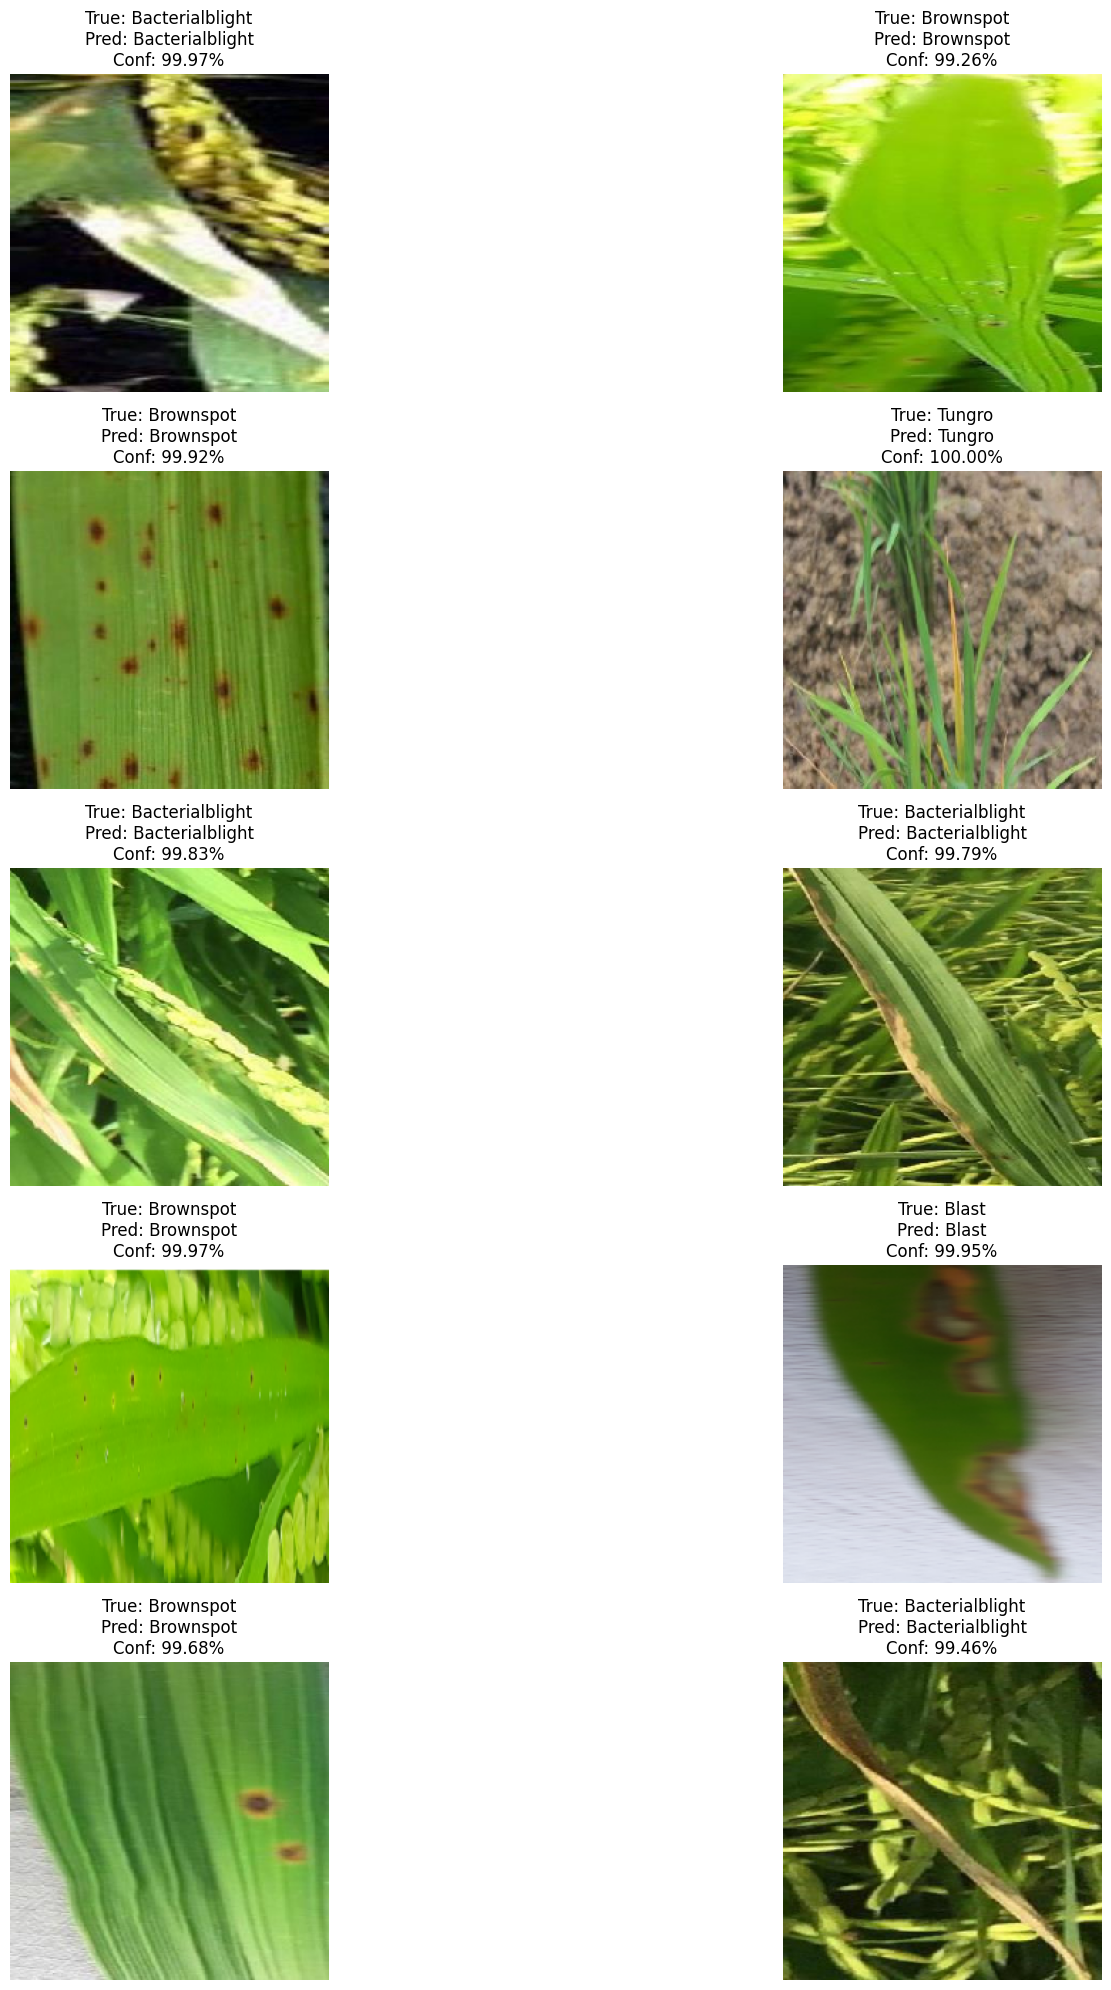

In [48]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications.efficientnet import preprocess_input

# ==========================================
# CLASS NAMES
# ==========================================

class_names = [
    'Bacterialblight',
    'Blast',
    'Brownspot',
    'Tungro'
]

# ==========================================
# TEST DIRECTORY
# ==========================================

# Changed test_dir from '/content/test' to balanced_path as '/content/test' does not exist.
test_dir = balanced_path

# ==========================================
# COLLECT TEST IMAGES
# ==========================================

test_images = []

for class_name in class_names:

    class_folder = os.path.join(
        test_dir,
        class_name
    )

    images = [

        os.path.join(class_folder, img)

        for img in os.listdir(class_folder)

        if img.lower().endswith(
            ('.jpg', '.jpeg', '.png')
        )
    ]

    test_images.extend(images)

# ==========================================
# RANDOMLY SELECT 10 IMAGES
# ==========================================

random_images = random.sample(
    test_images,
    10
)

# ==========================================
# PLOT SETTINGS
# ==========================================

plt.figure(figsize=(20,20))

# ==========================================
# PREDICT TEST IMAGES
# ==========================================

for i, img_path in enumerate(random_images):

    # -----------------------------
    # TRUE CLASS
    # -----------------------------

    true_class = img_path.split('/')[-2]

    # -----------------------------
    # LOAD IMAGE
    # -----------------------------

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    display_img = img

    # -----------------------------
    # IMAGE TO ARRAY
    # -----------------------------

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # -----------------------------
    # PREPROCESS
    # -----------------------------

    img_array = preprocess_input(
        img_array
    )

    # -----------------------------
    # PREDICTION
    # -----------------------------

    prediction = model.predict(
        img_array,
        verbose=0
    )

    pred_index = np.argmax(prediction)

    predicted_class = class_names[pred_index]

    confidence = np.max(prediction) * 100

    # -----------------------------
    # SHOW IMAGE
    # -----------------------------

    plt.subplot(5,2,i+1)

    plt.imshow(display_img)

    plt.axis('off')

    plt.title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}\n"
        f"Conf: {confidence:.2f}%"
    )

# ==========================================
# SHOW RESULTS
# ==========================================

plt.tight_layout()

plt.show()

predict on training images

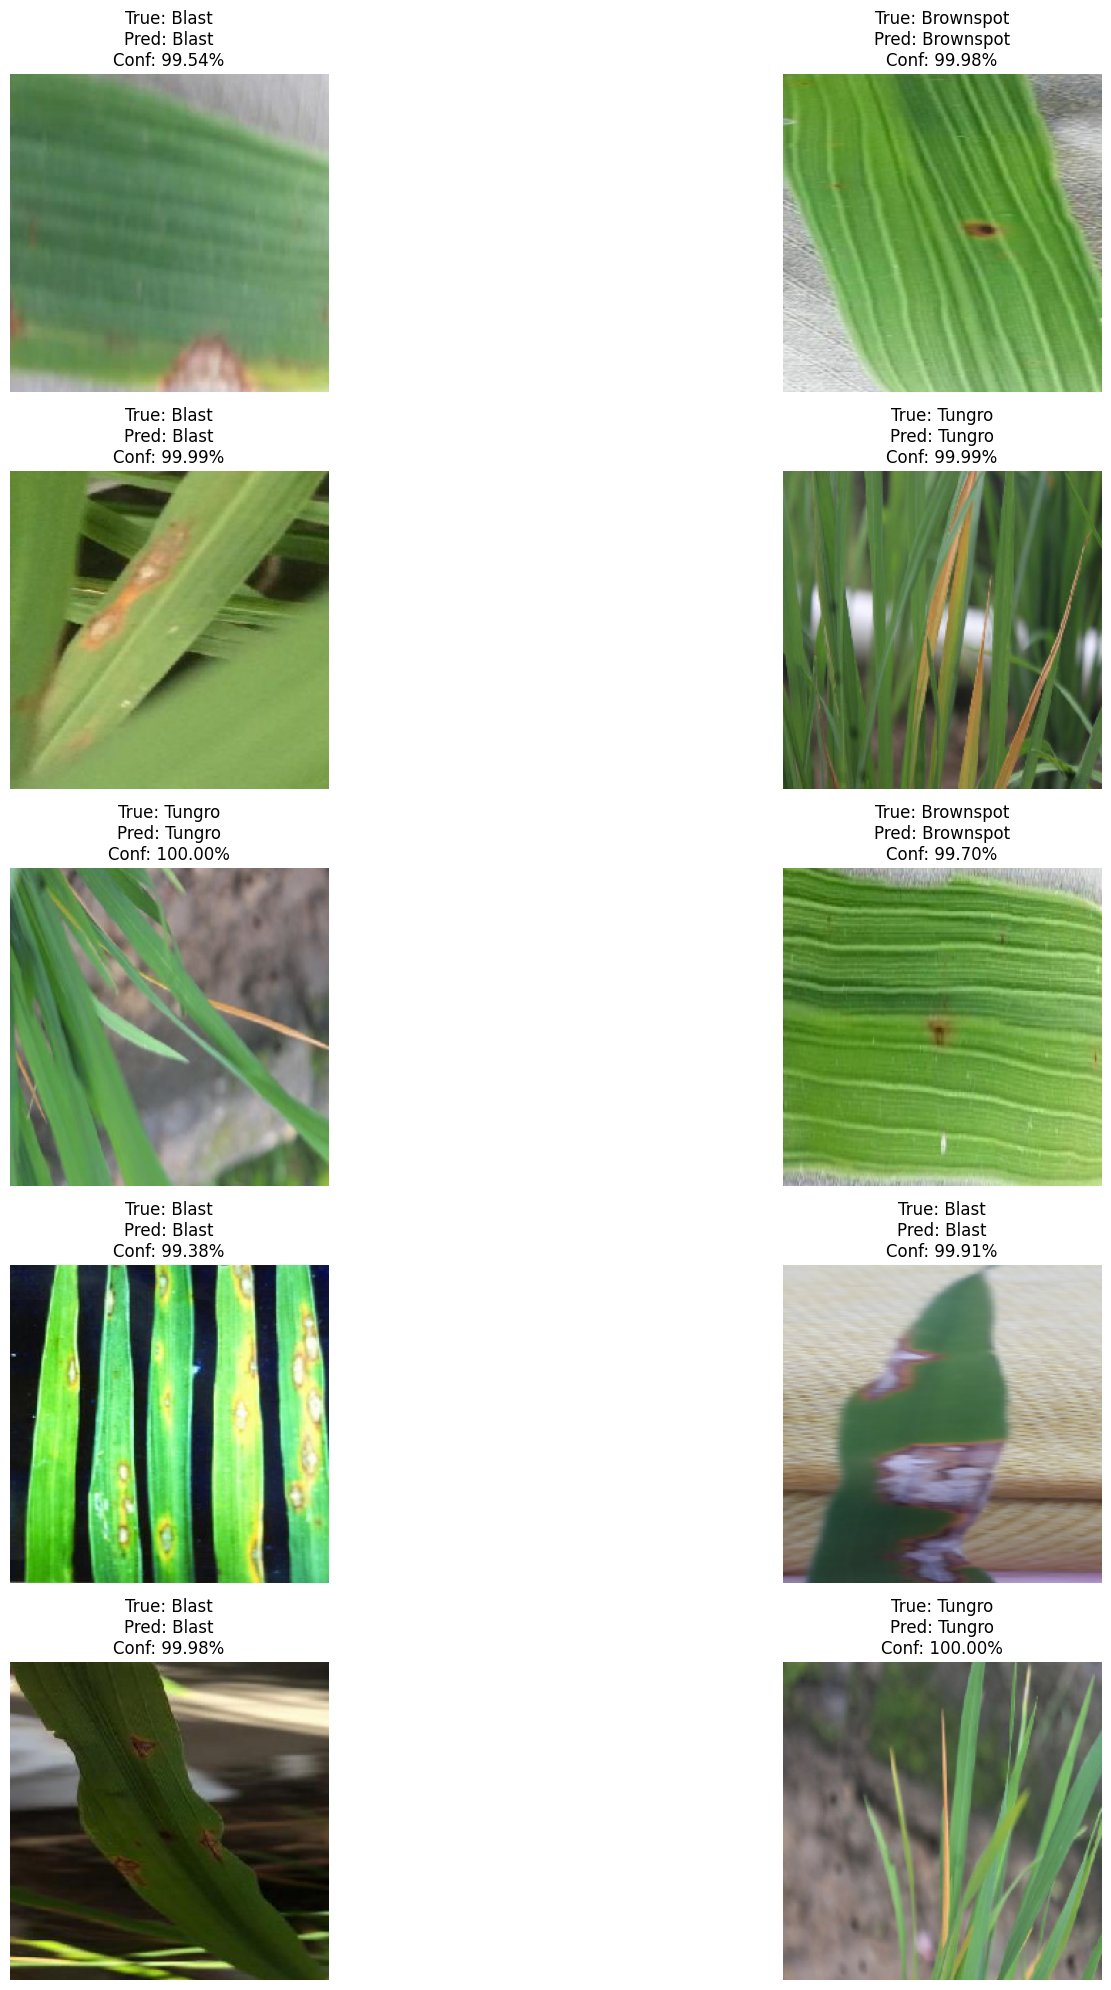

In [50]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications.efficientnet import preprocess_input

# ==========================================
# TRAIN DIRECTORY
# ==========================================

# The original '/content/train' directory does not exist. Changed to balanced_path.
train_dir = balanced_path

# ==========================================
# CLASS NAMES
# ==========================================

class_names = [
    'Bacterialblight',
    'Blast',
    'Brownspot',
    'Tungro'
]

# ==========================================
# COLLECT TRAIN IMAGES
# ==========================================

train_images = []

for class_name in class_names:

    class_folder = os.path.join(
        train_dir,
        class_name
    )

    images = [

        os.path.join(class_folder, img)

        for img in os.listdir(class_folder)

        if img.lower().endswith(
            ('.jpg', '.jpeg', '.png')
        )
    ]

    train_images.extend(images)

# ==========================================
# RANDOMLY SELECT 10 IMAGES
# ==========================================

random_images = random.sample(
    train_images,
    10
)

# ==========================================
# FIGURE
# ==========================================

plt.figure(figsize=(20,20))

# ==========================================
# PREDICTIONS
# ==========================================

for i, img_path in enumerate(random_images):

    # -----------------------------
    # TRUE LABEL
    # -----------------------------

    true_class = img_path.split('/')[-2]

    # -----------------------------
    # LOAD IMAGE
    # -----------------------------

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    display_img = img

    # -----------------------------
    # IMAGE ARRAY
    # -----------------------------

    img_array = image.img_to_array(img)

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # -----------------------------
    # PREPROCESS
    # -----------------------------

    img_array = preprocess_input(
        img_array
    )

    # -----------------------------
    # MODEL PREDICTION
    # -----------------------------

    prediction = model.predict(
        img_array,
        verbose=0
    )

    pred_index = np.argmax(prediction)

    predicted_class = class_names[pred_index]

    confidence = np.max(prediction) * 100

    # -----------------------------
    # SHOW IMAGE
    # -----------------------------

    plt.subplot(5,2,i+1)

    plt.imshow(display_img)

    plt.axis('off')

    plt.title(
        f"True: {true_class}\n"
        f"Pred: {predicted_class}\n"
        f"Conf: {confidence:.2f}%"
    )

# ==========================================
# SHOW RESULTS
# ==========================================

plt.tight_layout()

plt.show()

In [52]:
# ==========================================
# TRAIN EVALUATION GENERATOR
# IMPORTANT: shuffle=False
# ==========================================

train_eval_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    shuffle=False
)

Found 5232 images belonging to 4 classes.


In [53]:
# TRAIN
evaluate_dataset(
    train_eval_generator,
    "TRAIN"
)

# VALIDATION
evaluate_dataset(
    valid_generator,
    "VALIDATION"
)

# TEST
evaluate_dataset(
    test_generator,
    "TEST"
)


TRAIN RESULTS
Total Images: 5232
Correct Predictions: 5229
Wrong Predictions: 3
Accuracy: 99.94%

VALIDATION RESULTS
Total Images: 1044
Correct Predictions: 1044
Wrong Predictions: 0
Accuracy: 100.00%

TEST RESULTS
Total Images: 5232
Correct Predictions: 5232
Wrong Predictions: 0
Accuracy: 100.00%


test generator

In [61]:
import os
import shutil
import random

# ==========================================
# ORIGINAL DATASET
# ==========================================

dataset_path = "/content/balanced_rice_dataset"

# ==========================================
# NEW SPLIT DATASET
# ==========================================

base_dir = "/content/rice_split_dataset"

train_dir = os.path.join(base_dir, "train")

valid_dir = os.path.join(base_dir, "valid")

test_dir = os.path.join(base_dir, "test")

# ==========================================
# CREATE FOLDERS
# ==========================================

for folder in [train_dir, valid_dir, test_dir]:

    os.makedirs(folder, exist_ok=True)

# ==========================================
# CLASS NAMES
# ==========================================

class_names = os.listdir(dataset_path)

# ==========================================
# SPLIT DATASET
# ==========================================

for class_name in class_names:

    source_folder = os.path.join(
        dataset_path,
        class_name
    )

    images = os.listdir(source_folder)

    random.shuffle(images)

    total = len(images)

    # -----------------------------
    # SPLIT COUNTS
    # -----------------------------

    train_split = int(0.7 * total)

    valid_split = int(0.2 * total)

    # Remaining → test
    test_split = total - train_split - valid_split

    # -----------------------------
    # IMAGE SPLITS
    # -----------------------------

    train_images = images[:train_split]

    valid_images = images[
        train_split : train_split + valid_split
    ]

    test_images = images[
        train_split + valid_split :
    ]

    # -----------------------------
    # CREATE CLASS FOLDERS
    # -----------------------------

    for split_folder in [
        train_dir,
        valid_dir,
        test_dir
    ]:

        os.makedirs(
            os.path.join(split_folder, class_name),
            exist_ok=True
        )

    # -----------------------------
    # COPY TRAIN IMAGES
    # -----------------------------

    for img in train_images:

        shutil.copy(

            os.path.join(source_folder, img),

            os.path.join(
                train_dir,
                class_name,
                img
            )
        )

    # -----------------------------
    # COPY VALID IMAGES
    # -----------------------------

    for img in valid_images:

        shutil.copy(

            os.path.join(source_folder, img),

            os.path.join(
                valid_dir,
                class_name,
                img
            )
        )

    # -----------------------------
    # COPY TEST IMAGES
    # -----------------------------

    for img in test_images:

        shutil.copy(

            os.path.join(source_folder, img),

            os.path.join(
                test_dir,
                class_name,
                img
            )
        )

print("Dataset split completed!")

Dataset split completed!


train generator

In [62]:
train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    shuffle=True
)

Found 3660 images belonging to 4 classes.


Validation Generator

In [63]:
valid_generator = valid_datagen.flow_from_directory(

    valid_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    shuffle=False
)

Found 1044 images belonging to 4 classes.


test generator

In [64]:
test_generator = test_datagen.flow_from_directory(

    test_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode='categorical',

    shuffle=False
)

Found 528 images belonging to 4 classes.


In [65]:
print(train_generator.samples)

print(valid_generator.samples)

print(test_generator.samples)

3660
1044
528


final test evaluation

In [66]:
evaluate_dataset(
    test_generator,
    "TEST"
)


TEST RESULTS
Total Images: 528
Correct Predictions: 528
Wrong Predictions: 0
Accuracy: 100.00%


In [67]:
model.save("rice_disease_model.keras")

save model.tflite

In [68]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

with open(
    "rice_disease_model.tflite",
    "wb"
) as f:

    f.write(tflite_model)

print("TFLite Model Saved!")

Saved artifact at '/tmp/tmpcohry9jd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137149984409168: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137149984412048: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  137152610924112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137151034774864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137151034774672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137151034774480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137151034773136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137151034773328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137151034776592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137151034776784: TensorSpec(shape=(), dtype=tf.resource, name=None

In [69]:
class_names = [
    "Bacterialblight",
    "Blast",
    "Brownspot",
    "Tungro"
]

with open("labels.txt", "w") as f:

    for label in class_names:

        f.write(label + "\n")

gradcam

In [70]:
import tensorflow as tf

import numpy as np

import matplotlib.pyplot as plt

import cv2

from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications.efficientnet import preprocess_input

In [71]:
class_names = [
    'Bacterialblight',
    'Blast',
    'Brownspot',
    'Tungro'
]

In [73]:
import os

img_path = os.path.join(
    test_dir,
    class_names[0],
    os.listdir(os.path.join(test_dir, class_names[0]))[0]
)

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

img_array = preprocess_input(
    img_array
)

In [74]:
prediction = model.predict(img_array)

predicted_index = np.argmax(prediction)

predicted_class = class_names[predicted_index]

confidence = np.max(prediction) * 100

print("Predicted Class:", predicted_class)

print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Predicted Class: Bacterialblight
Confidence: 99.98468


In [75]:
last_conv_layer_name = "top_conv"

In [76]:
grad_model = tf.keras.models.Model(

    [model.inputs],

    [
        model.get_layer(
            last_conv_layer_name
        ).output,

        model.output
    ]
)

In [78]:
with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(img_array)

    loss = predictions[:, predicted_index]

# ==========================================
# COMPUTE GRADIENTS
# ==========================================

grads = tape.gradient(
    loss,
    conv_outputs
)

# ==========================================
# GLOBAL AVERAGE POOLING
# ==========================================

pooled_grads = tf.reduce_mean(
    grads,
    axis=(0,1,2)
)

# ==========================================
# FEATURE MAPS
# ==========================================

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

heatmap = tf.squeeze(heatmap)

# ==========================================
# NORMALIZE
# ==========================================

heatmap = np.maximum(
    heatmap,
    0
)

heatmap /= np.max(heatmap)



/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


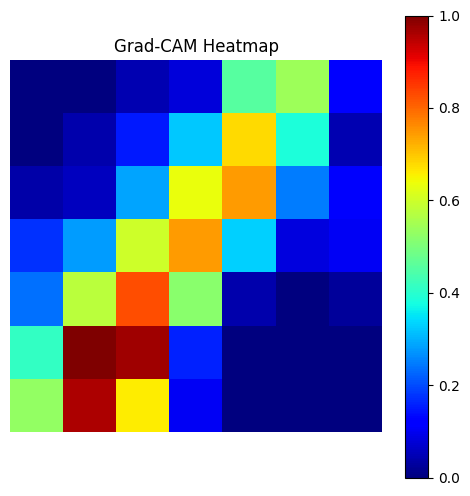

In [79]:
plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap='jet'
)

plt.colorbar()

plt.title("Grad-CAM Heatmap")

plt.axis('off')

plt.show()

In [80]:
# ==========================================
# LOAD ORIGINAL IMAGE
# ==========================================

original_img = cv2.imread(img_path)

original_img = cv2.cvtColor(
    original_img,
    cv2.COLOR_BGR2RGB
)

original_img = cv2.resize(
    original_img,
    (224,224)
)

# ==========================================
# RESIZE HEATMAP
# ==========================================

heatmap_resized = cv2.resize(
    heatmap,
    (224,224)
)

# ==========================================
# CONVERT TO COLOR MAP
# ==========================================

heatmap_resized = np.uint8(
    255 * heatmap_resized
)

heatmap_colored = cv2.applyColorMap(
    heatmap_resized,
    cv2.COLORMAP_JET
)

heatmap_colored = cv2.cvtColor(
    heatmap_colored,
    cv2.COLOR_BGR2RGB
)

# ==========================================
# OVERLAY
# ==========================================

superimposed_img = cv2.addWeighted(

    original_img,

    0.6,

    heatmap_colored,

    0.4,

    0
)

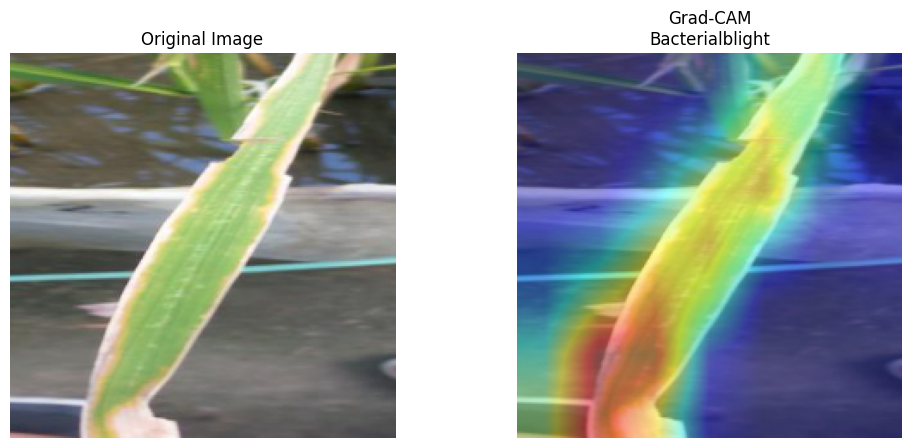

In [81]:
plt.figure(figsize=(12,5))

# ==========================================
# ORIGINAL IMAGE
# ==========================================

plt.subplot(1,2,1)

plt.imshow(original_img)

plt.title("Original Image")

plt.axis('off')

# ==========================================
# GRAD-CAM RESULT
# ==========================================

plt.subplot(1,2,2)

plt.imshow(superimposed_img)

plt.title(
    f"Grad-CAM\n{predicted_class}"
)

plt.axis('off')

plt.show()